In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [4]:
cols = ['TotalCharges', 'MonthlyCharges']
df[cols].describe().round(2)

,TotalCharges,MonthlyCharges
count,7043.00,7043.00
mean,2279.73,64.76
std,2266.79,30.09
min,0.00,18.25
25%,398.55,35.50
50%,1394.55,70.35
75%,3786.60,89.85
max,8684.80,118.75


In [5]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
X = df[cols]
X_mm = mm.fit_transform(X)
X_mm_df = pd.DataFrame(X_mm, columns=cols)
X_mm_df.agg(['min', 'max']).round(2)

,TotalCharges,MonthlyCharges
min,0.0,0.0
max,1.0,1.0


In [6]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X_std = std.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=cols)
X_std_df.describe().round(2)

,TotalCharges,MonthlyCharges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.01,-1.55
25%,-0.83,-0.97
50%,-0.39,0.19
75%,0.66,0.83
max,2.83,1.79


In [7]:
from sklearn.preprocessing import RobustScaler
rb = RobustScaler()
X_rb = rb.fit_transform(X)
X_rb_df = pd.DataFrame(X_rb, columns=cols)
X_rb_df.describe().round(2)

,TotalCharges,MonthlyCharges
count,7043.00,7043.00
mean,0.26,-0.10
std,0.67,0.55
min,-0.41,-0.96
25%,-0.29,-0.64
50%,0.00,0.00
75%,0.71,0.36
max,2.15,0.89


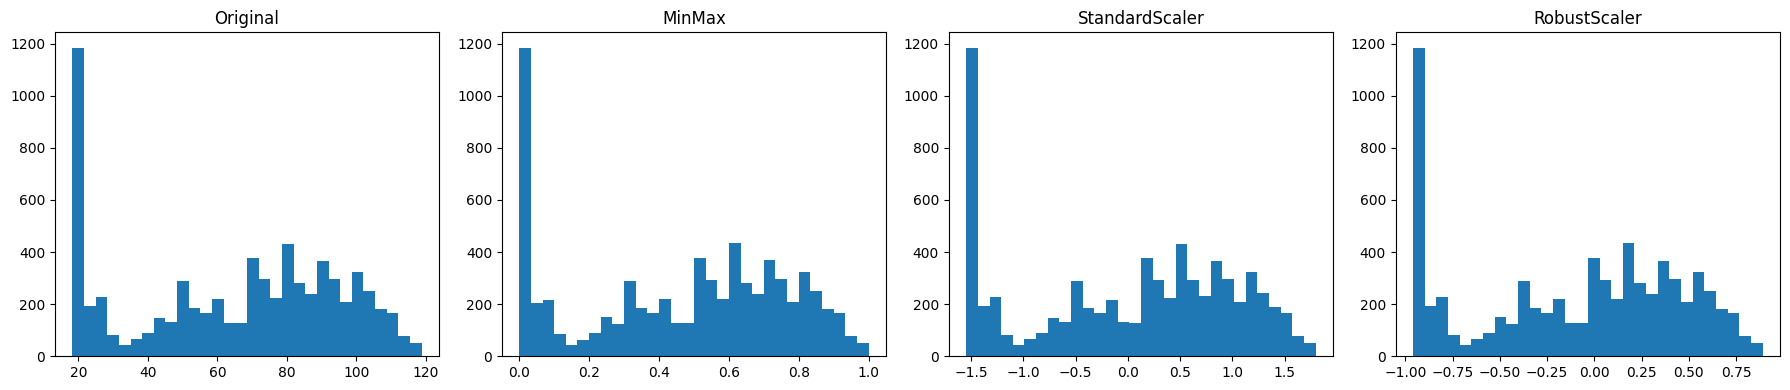

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].hist(df['MonthlyCharges'], bins=30); ax[0].set_title('Original')
ax[1].hist(X_mm_df['MonthlyCharges'], bins=30); ax[1].set_title('MinMax')
ax[2].hist(X_std_df['MonthlyCharges'], bins=30); ax[2].set_title('StandardScaler')
ax[3].hist(X_rb_df['MonthlyCharges'], bins=30); ax[3].set_title('RobustScaler')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_test_S = scaler.fit_transform(X_test)

In [12]:
print(X_train_S.mean(axis=0).round(2))
print(X_test_S.mean(axis=0).round(2))

[-0.  0.]
[-0. -0.]
